# ERA5 data

In [2]:
##Belgium
import xarray as xr
import pandas as pd

#Read all ERA5 hazard documents

BE_2015 = xr.open_dataset('/Users/axelleclaes/Desktop/Data België/2015/data_stream-oper_stepType-max.nc')
BE_2016 = xr.open_dataset('/Users/axelleclaes/Desktop/Data België/2016/data_stream-oper_stepType-max.nc')
BE_2017 = xr.open_dataset('/Users/axelleclaes/Desktop/Data België/2017/data_stream-oper_stepType-max.nc')
BE_2018 = xr.open_dataset('/Users/axelleclaes/Desktop/Data België/2018/data_stream-oper_stepType-max.nc')
BE_2019 = xr.open_dataset('/Users/axelleclaes/Desktop/Data België/2019/data_stream-oper_stepType-max.nc')
BE_2020 = xr.open_dataset('/Users/axelleclaes/Desktop/Data België/2020/data_stream-oper_stepType-max.nc')
BE_2021 = xr.open_dataset('/Users/axelleclaes/Desktop/Data België/2021/data_stream-oper_stepType-max.nc')
BE_2022 = xr.open_dataset('/Users/axelleclaes/Desktop/Data België/2022/data_stream-oper_stepType-max.nc')
BE_2023 = xr.open_dataset('/Users/axelleclaes/Desktop/Data België/2023/data_stream-oper_stepType-max.nc')
BE_2024 = xr.open_dataset('/Users/axelleclaes/Desktop/Data België/2024/data_stream-oper_stepType-max.nc')

ds_combined_BE = xr.concat([BE_2015, BE_2016, BE_2017, BE_2018, BE_2019, BE_2020, BE_2021, BE_2022, BE_2023, BE_2024], dim="valid_time")

era_df = ds_combined_BE.to_dataframe().reset_index()
era_df

era_df

,valid_time,latitude,longitude,fg10,number,expver
0,2015-01-01 00:00:00,51.5,2.50,13.039871,0,0001
1,2015-01-01 00:00:00,51.5,2.75,12.921707,0,0001
2,2015-01-01 00:00:00,51.5,3.00,12.243973,0,0001
3,2015-01-01 00:00:00,51.5,3.25,10.675613,0,0001
4,2015-01-01 00:00:00,51.5,3.50,9.477371,0,0001
...,...,...,...,...,...,...
6300283,2024-12-31 23:00:00,49.5,5.25,10.525099,0,0001
6300284,2024-12-31 23:00:00,49.5,5.50,10.528028,0,0001
6300285,2024-12-31 23:00:00,49.5,5.75,10.328810,0,0001
6300286,2024-12-31 23:00:00,49.5,6.00,9.947950,0,0001


# KMI data

In [3]:
from openkmi.point_obs import Synop
import pandas as pd
import re

# 1. Stations load
def load_kmi_stations():
    kmi = Synop()
    df_stations = kmi.get_stations()

    def parse_point(geom_str):
        match = re.search(r"POINT \(([0-9.]+) ([0-9.]+)\)", geom_str)
        if match:
            return float(match.group(1)), float(match.group(2))
        return None, None

    df_stations[["lat", "lon"]] = df_stations["the_geom"].apply(
        lambda x: pd.Series(parse_point(x))
    )
    return df_stations

#2. Data per station
def load_kmi_wind_hourly(station_code, start="2015-01-01", end="2024-12-31"):
    kmi = Synop()

    df = kmi.get_data(
        station_code,
        start_date=f"{start}T00:00:00",
        end_date=f"{end}T23:59:59",
        parameter_list=["wind_peak_speed"],
    )

    if df.empty or "wind_peak_speed" not in df.columns:
        return pd.DataFrame()

    df = df.reset_index()

    # Important keep dataset
    df["datetime"] = pd.to_datetime(df["timestamp"])

    df["kmi_gust_ms"] = pd.to_numeric(df["wind_peak_speed"], errors="coerce")

    return df[["datetime", "kmi_gust_ms"]]

# 3. loop
def load_all_kmi_wind_hourly(start="2015-01-01", end="2024-12-31"):
    df_stations = load_kmi_stations()

    alle_data = []

    for _, station in df_stations.iterrows():
        code = str(station["code"])

        df_wind = load_kmi_wind_hourly(code, start, end)
        if df_wind.empty:
            continue

        df_wind["station_code"] = code
        df_wind["station_name"] = station["name"]
        df_wind["lat"] = station["lat"]
        df_wind["lon"] = station["lon"]

        alle_data.append(df_wind)

    return pd.concat(alle_data, ignore_index=True)


# 4. Run
df_kmi_all = load_all_kmi_wind_hourly()

In [4]:
import pandas as pd

# Ensure that date is a datetime column.
df_kmi_all['datetime'] = pd.to_datetime(df_kmi_all['datetime'])

#Define the months you want to retain.
maanden_winter = [1, 2, 3, 10, 11, 12]

# Filter the DataFrame by these months.
df_kmi_filtered = df_kmi_all[df_kmi_all['datetime'].dt.month.isin(maanden_winter)].copy()

print(f"Total rows after filtering: {len(df_kmi_filtered)}")
print(df_kmi_filtered.head())

Total rows after filtering: 1260869
                   datetime  kmi_gust_ms station_code station_name        lat  \
0 2015-01-01 00:00:00+00:00          1.9         6477   DIEPENBEEK  50.915458   
1 2015-01-01 01:00:00+00:00          1.3         6477   DIEPENBEEK  50.915458   
2 2015-01-01 02:00:00+00:00          1.9         6477   DIEPENBEEK  50.915458   
3 2015-01-01 03:00:00+00:00          1.9         6477   DIEPENBEEK  50.915458   
4 2015-01-01 04:00:00+00:00          4.5         6477   DIEPENBEEK  50.915458   

        lon  
0  5.450296  
1  5.450296  
2  5.450296  
3  5.450296  
4  5.450296  


# Analyse: KMI VS ERA5

ERA5 loaded
KMI loaded
Matching done
ERA per station ready
Merge done: 1325647
Correlatie: 0.732
Bias: -0.027 m/s
RMSE: 3.019 m/s


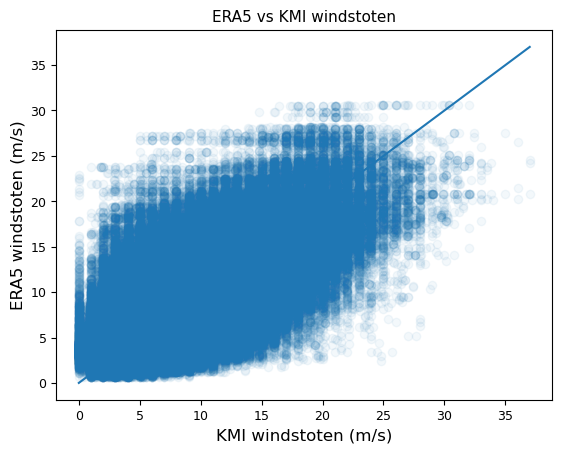

In [5]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openkmi.point_obs import Synop
import re

# =====================================================
# 1. ERA5 DATA 
# =====================================================

files = [
    '/Users/axelleclaes/Desktop/Data België/2015/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2016/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2017/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2018/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2019/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2020/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2021/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2022/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2023/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2024/data_stream-oper_stepType-max.nc'
]

datasets = [xr.open_dataset(f) for f in files]
ds_combined = xr.concat(datasets, dim="valid_time")

era_df = ds_combined.to_dataframe().reset_index()

# Enkel relevante kolommen
era_df = era_df[['valid_time','latitude','longitude','fg10']]
era_df = era_df.rename(columns={'valid_time':'datetime', 'fg10':'era_gust_ms'})

# Zorg dat datetime hetzelfde formaat heeft
era_df['datetime'] = pd.to_datetime(era_df['datetime']).dt.tz_localize(None)

print("ERA5 loaded")

# =====================================================
# 2. KMI STATIONS
# =====================================================

def load_kmi_stations():
    kmi = Synop()
    df_stations = kmi.get_stations()

    def parse_point(geom_str):
        match = re.search(r"POINT \(([0-9.]+) ([0-9.]+)\)", geom_str)
        if match:
            return float(match.group(1)), float(match.group(2))
        return None, None

    df_stations[["lon","lat"]] = df_stations["the_geom"].apply(
        lambda x: pd.Series(parse_point(x))
    )

    return df_stations[['code','name','lat','lon']]

# =====================================================
# 3. KMI DATA
# =====================================================

def load_kmi_data(start="2015-01-01", end="2024-12-31"):
    kmi = Synop()
    stations = load_kmi_stations()

    all_data = []

    for _, station in stations.iterrows():
        code = str(station['code'])

        df = kmi.get_data(
            code,
            start_date=f"{start}T00:00:00",
            end_date=f"{end}T23:59:59",
            parameter_list=["wind_peak_speed"],
        )

        if df.empty or "wind_peak_speed" not in df.columns:
            continue

        df = df.reset_index()
        df['datetime'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None)
        df['kmi_gust_ms'] = pd.to_numeric(df['wind_peak_speed'], errors='coerce')

        df['station_code'] = code
        df['station_name'] = station['name']
        df['lat'] = station['lat']
        df['lon'] = station['lon']

        all_data.append(df[['datetime','kmi_gust_ms','station_code','station_name','lat','lon']])

    return pd.concat(all_data, ignore_index=True)

df_kmi = load_kmi_data()

# Winterfilter
winter_months = [1,2,3,10,11,12]
df_kmi = df_kmi[df_kmi['datetime'].dt.month.isin(winter_months)]

print("KMI loaded")

# =====================================================
# 4. MATCH STATION -> ERA5 GRID
# =====================================================

def find_nearest_grid(lat, lon, era_coords):
    dist = (era_coords[:,0] - lat)**2 + (era_coords[:,1] - lon)**2
    idx = np.argmin(dist)
    return era_coords[idx]

# unieke ERA gridpunten
era_coords = era_df[['latitude','longitude']].drop_duplicates().values

stations = df_kmi[['station_code','lat','lon']].drop_duplicates()

matches = []

for _, row in stations.iterrows():
    nearest = find_nearest_grid(row['lat'], row['lon'], era_coords)

    matches.append({
        'station_code': row['station_code'],
        'era_lat': nearest[0],
        'era_lon': nearest[1]
    })

df_match = pd.DataFrame(matches)

print("Matching done")

# =====================================================
# 5. ERA5 PER STATION
# =====================================================

era_station_list = []

for _, row in df_match.iterrows():
    subset = era_df[
        (era_df['latitude'] == row['era_lat']) &
        (era_df['longitude'] == row['era_lon'])
    ].copy()

    subset['station_code'] = row['station_code']

    era_station_list.append(subset[['datetime','station_code','era_gust_ms']])

era_station_df = pd.concat(era_station_list)

print("ERA per station ready")

# =====================================================
# 6. MERGE
# =====================================================

df_merged = pd.merge(
    df_kmi,
    era_station_df,
    on=['datetime','station_code'],
    how='inner'
)

df_merged = df_merged.dropna()

print("Merge done:", len(df_merged))

# =====================================================
# 7. VALIDATIE METRICS
# =====================================================

corr = df_merged[['kmi_gust_ms','era_gust_ms']].corr().iloc[0,1]
bias = (df_merged['era_gust_ms'] - df_merged['kmi_gust_ms']).mean()
rmse = np.sqrt(((df_merged['era_gust_ms'] - df_merged['kmi_gust_ms'])**2).mean())

print(f"Correlatie: {corr:.3f}")
print(f"Bias: {bias:.3f} m/s")
print(f"RMSE: {rmse:.3f} m/s")

# =====================================================
# 8. PLOT
# =====================================================

plt.figure()
plt.scatter(df_merged['kmi_gust_ms'], df_merged['era_gust_ms'], alpha=0.05)

max_val = max(df_merged['kmi_gust_ms'].max(), df_merged['era_gust_ms'].max())

plt.plot([0, max_val], [0, max_val])  # 1:1 lijn
plt.xlabel("KMI windstoten (m/s)")
plt.ylabel("ERA5 windstoten (m/s)")
plt.title("ERA5 vs KMI windstoten")
plt.show()

In [6]:
# Extremes (>20 m/s)
df_extreme = df_merged[df_merged['kmi_gust_ms'] > 22.2]

print("number of extreme events:", len(df_extreme))

corr_extreme = df_extreme[['kmi_gust_ms','era_gust_ms']].corr().iloc[0,1]
print("Correlation extremes:", corr_extreme)

number of extreme events: 4334
Correlation extremes: 0.20923851008326597


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Werk met een kopie en verwijder missende waarden
plot_df = df_merged[["datetime", "station_code", "station_name", "kmi_gust_ms", "era_gust_ms"]].dropna().copy()
plot_df["datetime"] = pd.to_datetime(plot_df["datetime"])

# Algemene statistieken
corr_all = plot_df["kmi_gust_ms"].corr(plot_df["era_gust_ms"])
bias_all = (plot_df["era_gust_ms"] - plot_df["kmi_gust_ms"]).mean()
rmse_all = np.sqrt(((plot_df["era_gust_ms"] - plot_df["kmi_gust_ms"]) ** 2).mean())

# Extremes
threshold = 22.2
df_extreme = plot_df[plot_df["kmi_gust_ms"] > threshold].copy()
corr_extreme = df_extreme["kmi_gust_ms"].corr(df_extreme["era_gust_ms"])

print(f"Correlation (all data): {corr_all:.3f}")
print(f"Bias (ERA5 - KMI): {bias_all:.3f} m/s")
print(f"RMSE: {rmse_all:.2f} m/s")
print(f"Correlation extreme windgust(> {threshold} m/s): {corr_extreme:.3f}")
print(f"number of extreme cases: {len(df_extreme)}")

Correlation (all data): 0.732
Bias (ERA5 - KMI): -0.027 m/s
RMSE: 3.02 m/s
Correlation extreme windgust(> 22.2 m/s): 0.209
number of extreme cases: 4334


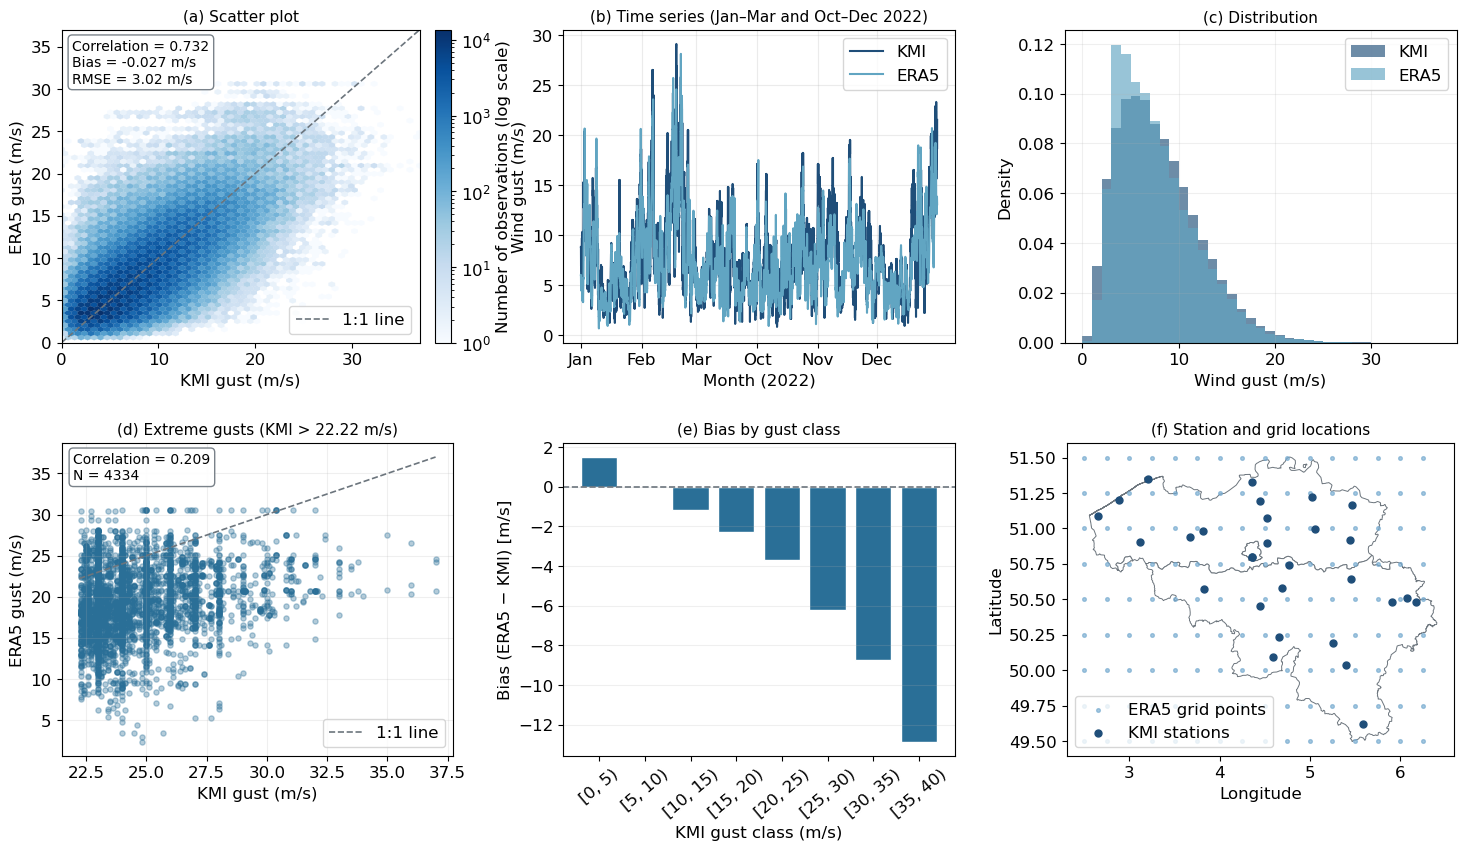

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd

# =========================================================
#  Style and colors
# =========================================================
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 12,     
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

blue_dark = "#1f4e79"        # KMI
blue_main = "#2a6f97"        # main blue
blue_light = "#61a5c2"       # ERA5 lines
blue_very_light = "#74a9cf"  # ERA5 points on map
grey = "#6c757d"

# =========================================================
#  Prepare data
# =========================================================
plot_df = df_merged[["datetime", "station_code", "station_name", "kmi_gust_ms", "era_gust_ms"]].dropna().copy()
plot_df["datetime"] = pd.to_datetime(plot_df["datetime"], utc=True, errors="coerce")
plot_df = plot_df.dropna(subset=["datetime"])

# General metrics
corr_all = plot_df["kmi_gust_ms"].corr(plot_df["era_gust_ms"])
bias_all = (plot_df["era_gust_ms"] - plot_df["kmi_gust_ms"]).mean()
rmse_all = np.sqrt(((plot_df["era_gust_ms"] - plot_df["kmi_gust_ms"]) ** 2).mean())

# Extreme gusts
threshold = 22.22
df_extreme = plot_df[plot_df["kmi_gust_ms"] > threshold].copy()
corr_extreme = df_extreme["kmi_gust_ms"].corr(df_extreme["era_gust_ms"])

# Bias by class
bias_df = plot_df.copy()
bias_df["bin"] = pd.cut(
    bias_df["kmi_gust_ms"],
    bins=np.arange(0, 41, 5),
    right=False
)

summary = bias_df.groupby("bin", observed=False).apply(
    lambda x: pd.Series({
        "mean_bias": (x["era_gust_ms"] - x["kmi_gust_ms"]).mean(),
        "count": len(x)
    })
).reset_index()


station_to_plot = "UCCLE-UKKEL"

ts = plot_df[plot_df["station_name"] == station_to_plot].copy()
ts = ts.sort_values("datetime")

ts["year"] = ts["datetime"].dt.year
ts["month"] = ts["datetime"].dt.month

ts_2022 = ts[
    (ts["year"] == 2022) &
    (ts["month"].isin([1, 2, 3, 10, 11, 12]))
].copy()

ts_2022 = ts_2022.sort_values("datetime").reset_index(drop=True)
ts_2022["time_index"] = range(len(ts_2022))

# =========================================================
#  Map data
# =========================================================

# Belgium shapefile
belgie_prov = gpd.read_file(
    "/Users/axelleclaes/Desktop/wetrransfer_thesis_2025-11-07_0852/gadm41_BEL_shp/gadm41_BEL_1.shp".replace("wetrransfer", "wetransfer"),
    engine="fiona"
)

# KMI stations
stations = df_kmi_all[["station_code", "station_name", "lat", "lon"]].drop_duplicates().copy()
stations_gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["lon"], stations["lat"]),
    crs="EPSG:4326"
)

# ERA5 grid points
era5_points = era_df[["latitude", "longitude"]].drop_duplicates().copy()
era5_gdf = gpd.GeoDataFrame(
    era5_points,
    geometry=gpd.points_from_xy(era5_points["longitude"], era5_points["latitude"]),
    crs="EPSG:4326"
)

# Reproject if needed
if belgie_prov.crs != stations_gdf.crs:
    belgie_prov = belgie_prov.to_crs(stations_gdf.crs)

if era5_gdf.crs != stations_gdf.crs:
    era5_gdf = era5_gdf.to_crs(stations_gdf.crs)

# =========================================================
#  Create multipanel figure
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.subplots_adjust(bottom=0.22, wspace=0.28, hspace=0.32)

# ---------------------------------------------------------
# (a) Scatter plot
# ---------------------------------------------------------
ax = axes[0, 0]

hb = ax.hexbin(
    plot_df["kmi_gust_ms"],
    plot_df["era_gust_ms"],
    gridsize=55,
    mincnt=1,
    cmap=mpl.cm.Blues,
    bins="log",
    linewidths=0.15
)

max_val = max(plot_df["kmi_gust_ms"].max(), plot_df["era_gust_ms"].max())
ax.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color=grey,
    linewidth=1.2,
    label="1:1 line"
)

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel("KMI gust (m/s)", fontsize=12)
ax.set_ylabel("ERA5 gust (m/s)", fontsize=12)
ax.set_title("(a) Scatter plot")

textstr = (
    f"Correlation = {corr_all:.3f}\n"
    f"Bias = {bias_all:.3f} m/s\n"
    f"RMSE = {rmse_all:.2f} m/s"
)

ax.text(
    0.03, 0.97, textstr,
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor=grey)
)

ax.legend(loc="lower right", frameon=True)

cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Number of observations (log scale)", fontsize=12)

# ---------------------------------------------------------
# (b) Time series (2022 without Apr–Sep)
# ---------------------------------------------------------
month_ticks = []
month_labels = []
current_month = None

for i, row in ts_2022.iterrows():
    if row["month"] != current_month:
        month_ticks.append(i)
        month_labels.append(row["datetime"].strftime("%b"))
        current_month = row["month"]

ax = axes[0, 1]

ax.plot(
    ts_2022["time_index"],
    ts_2022["kmi_gust_ms"],
    color=blue_dark,
    linewidth=1.5,
    label="KMI"
)

ax.plot(
    ts_2022["time_index"],
    ts_2022["era_gust_ms"],
    color=blue_light,
    linewidth=1.5,
    label="ERA5"
)

ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels)

ax.set_xlabel("Month (2022)", fontsize=12)
ax.set_ylabel("Wind gust (m/s)", fontsize=12)
ax.set_title("(b) Time series (Jan–Mar and Oct–Dec 2022)")

ax.legend(frameon=True)
ax.grid(True, alpha=0.25)

# ---------------------------------------------------------
# (c) Distribution
# ---------------------------------------------------------
ax = axes[0, 2]

bins = np.arange(0, max_val + 1, 1)

ax.hist(
    plot_df["kmi_gust_ms"],
    bins=bins,
    density=True,
    alpha=0.65,
    color=blue_dark,
    label="KMI"
)

ax.hist(
    plot_df["era_gust_ms"],
    bins=bins,
    density=True,
    alpha=0.65,
    color=blue_light,
    label="ERA5"
)

ax.set_xlabel("Wind gust (m/s)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("(c) Distribution")
ax.legend(frameon=True)
ax.grid(True, alpha=0.20)

# ---------------------------------------------------------
# (d) Extreme gusts
# ---------------------------------------------------------
ax = axes[1, 0]

if len(df_extreme) > 0:
    max_ext = max(df_extreme["kmi_gust_ms"].max(), df_extreme["era_gust_ms"].max())
else:
    max_ext = 30

ax.scatter(
    df_extreme["kmi_gust_ms"],
    df_extreme["era_gust_ms"],
    color=blue_main,
    alpha=0.35,
    s=14
)

ax.plot(
    [threshold, max_ext],
    [threshold, max_ext],
    linestyle="--",
    color=grey,
    linewidth=1.2,
    label="1:1 line"
)

ax.set_xlabel("KMI gust (m/s)", fontsize=12)
ax.set_ylabel("ERA5 gust (m/s)", fontsize=12)
ax.set_title(f"(d) Extreme gusts (KMI > {threshold} m/s)")

ax.text(
    0.03, 0.97,
    f"Correlation = {corr_extreme:.3f}\nN = {len(df_extreme)}",
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor=grey)
)

ax.legend(frameon=True)
ax.grid(True, alpha=0.20)

# ---------------------------------------------------------
# (e) Bias by gust class
# ---------------------------------------------------------
ax = axes[1, 1]

ax.bar(
    summary["bin"].astype(str),
    summary["mean_bias"],
    color=blue_main,
    edgecolor="white"
)

ax.axhline(0, linestyle="--", color=grey, linewidth=1.2)
ax.set_xlabel("KMI gust class (m/s)", fontsize=12)
ax.set_ylabel("Bias (ERA5 − KMI) [m/s]", fontsize=12)
ax.set_title("(e) Bias by gust class")
ax.tick_params(axis="x", rotation=40)
ax.grid(True, axis="y", alpha=0.20)

# ---------------------------------------------------------
# (f) Map
# ---------------------------------------------------------
ax = axes[1, 2]

belgie_prov.plot(
    ax=ax,
    edgecolor=grey,
    facecolor="white",
    linewidth=0.7
)

era5_gdf.plot(
    ax=ax,
    color=blue_very_light,
    markersize=7,
    alpha=0.65,
    label="ERA5 grid points"
)

stations_gdf.plot(
    ax=ax,
    color=blue_dark,
    markersize=25,
    label="KMI stations"
)

ax.set_title("(f) Station and grid locations")
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.legend(frameon=True, loc="lower left")

# =========================================================
#  Force x- and y-axis labels to size 12 everywhere
# =========================================================
for ax in axes.flat:
    ax.xaxis.label.set_size(12)
    ax.yaxis.label.set_size(12)

# Ook de colorbar label op grootte 12
cb.ax.yaxis.label.set_size(12)

# =========================================================
# Save each subplot separately
# =========================================================
fig.canvas.draw()  

names = [
    "a_scatter_plot",
    "b_time_series",
    "c_distribution",
    "d_extreme_gusts",
    "e_bias_by_class",
    "f_map"
]

for ax, name in zip(axes.flat, names):
    extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(
        fig.dpi_scale_trans.inverted()
    )
    fig.savefig(
        f"{name}.png",
        dpi=300,
        bbox_inches=extent.expanded(1.05, 1.08)
    )

# =========================================================
# Save full figure
# =========================================================
plt.savefig("figure_wind_gusts.png", dpi=300, bbox_inches="tight")

plt.show()